In [ ]:
# --- Colab bootstrap -------------------------------------------------------
# No-op when you already have the thermo package alongside this notebook (the
# normal case: you cloned the repository and are running from code/chNN/).
# In Colab there is no repository, so fetch the package and the property data.
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# Figure 6.4-3 &mdash; oxygen $P$&ndash;$\underline{V}$ diagram (thermo-package version)

This is the package version of the Figure 6.4-3 notebook. Instead of coding the
Peng&ndash;Robinson equation of state and its fugacity by hand, it imports
`PengRobinson` from the shared `thermo` package and pulls oxygen's properties
from `code/data/pure_property.csv` with `from_database`. Compare it with the
self-contained `PR_isotherms_O2_example.ipynb`, which builds everything inline &mdash;
this is the book's "two ways to work."

**Numbers differ slightly from the self-contained notebook.** `from_database`
uses the tabulated acentric factor ($\omega = 0.025$, so $\kappa = 0.413$),
whereas the self-contained notebook uses the book's Illustration 6.4-1 value
($\kappa = 0.4069$). The two-phase envelope is essentially indistinguishable
(e.g. $P^{\mathrm{sat}}$ at $-175\,^{\circ}$C is 2.16 vs 2.19 bar).

Eric Furst
July 2026

In [5]:
import sys
sys.path.append("..")           # so `import thermo` finds code/thermo

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from thermo import PengRobinson

pr = PengRobinson.from_database("oxygen")
print(f"{pr.name}: Tc = {pr.Tc} K, Pc = {pr.Pc/1e5:.2f} bar, "
      f"omega = {pr.omega}, kappa = {pr.kappa:.4f}")

TO_KELVIN = 273.15
BAR = 1e5
M3_PER_KMOL = 1e3


oxygen: Tc = 154.6 K, Pc = 50.40 bar, omega = 0.025, kappa = 0.4130


## Saturation envelope

The package offers `pr.vapor_pressure(T)` (a Newton solve), but near the critical
point the van der Waals loop it must sit inside shrinks and Newton loses its
footing. To reach closer to $T_c$ we **bracket** the equal-fugacity root between
the loop's spinodal pressures — its local pressure maximum and minimum — and
solve by bisection, using the package building blocks `pr.pressure` and
`pr.ln_phi`. The grid is clustered toward $T_c$, and we close the curve with the
exact critical point $(\underline{V}_c, P_c)$.

In [6]:
from scipy.optimize import brentq


def loop_pressure_bounds(T, n=4000):
    """Spinodal pressures (loop max, loop min) of the sub-critical isotherm;
    None once the loop has vanished (T >= Tc)."""
    V = np.logspace(np.log10(1.001 * pr.b), np.log10(0.02), n)
    P = pr.pressure(V, T)
    turns = np.where(np.diff(np.sign(np.diff(P))) != 0)[0]
    if len(turns) < 2:
        return None
    return P[turns].min(), P[turns].max()


def Psat(T):
    """Saturation pressure (Pa): bracket between the spinodal pressures and
    solve ln(f^L) = ln(f^V) by bisection (robust up to the critical point)."""
    bounds = loop_pressure_bounds(T)
    if bounds is None:
        return None
    P_lo, P_hi = max(1.0, bounds[0]) * 1.0001, bounds[1] * 0.9999
    resid = lambda P: pr.ln_phi(T, P, "liquid") - pr.ln_phi(T, P, "vapor")
    if resid(P_lo) * resid(P_hi) > 0:
        return None
    return brentq(resid, P_lo, P_hi, xtol=1.0, rtol=1e-12, maxiter=200)


# grid clustered toward Tc: spacing shrinks near the critical point
frac = np.geomspace(2e-3, 1.0, 500)
T_list = np.sort(pr.Tc - (pr.Tc - 60.0) * frac)

rows = []
for T in T_list:
    ps = Psat(T)
    if ps is None:
        continue
    zs = pr.compressibility(T, ps)
    if len(zs) < 2 or (zs.max() - zs.min()) < 1e-7:   # roots merged -> at the top
        continue
    vL = pr.molar_volume(T, ps, "liquid")
    vV = pr.molar_volume(T, ps, "vapor")
    rows.append({"T": T, "P": ps, "vL": vL, "vV": vV})

# close the envelope exactly at the critical point
Vc = pr.molar_volume(pr.Tc, pr.Pc, "vapor")
rows.append({"T": pr.Tc, "P": pr.Pc, "vL": Vc, "vV": Vc})

envelope = pd.DataFrame(rows).sort_values("T").reset_index(drop=True)
print(f"{len(envelope)} points; approaches within "
      f"{pr.Tc - envelope['T'].iloc[-2]:.2f} K of Tc "
      f"(top point {envelope['P'].iloc[-2]/BAR:.2f} bar, Pc = {pr.Pc/BAR:.2f} bar)")
envelope.tail()


501 points; approaches within 0.19 K of Tc (top point 50.05 bar, Pc = 50.40 bar)


,T,P,vL,vV
496,154.403597,5.003769e+06,0.000071,0.000087
497,154.406028,5.004221e+06,0.000071,0.000087
498,154.408429,5.004668e+06,0.000071,0.000087
499,154.410800,5.005110e+06,0.000071,0.000087
500,154.600000,5.040000e+06,0.000082,0.000082


## Figure 6.4-3

Same construction as the self-contained notebook: supercritical isotherms, the
sub-critical isotherms with their loops replaced by horizontal tie lines, the
saturation envelope, and the critical point.

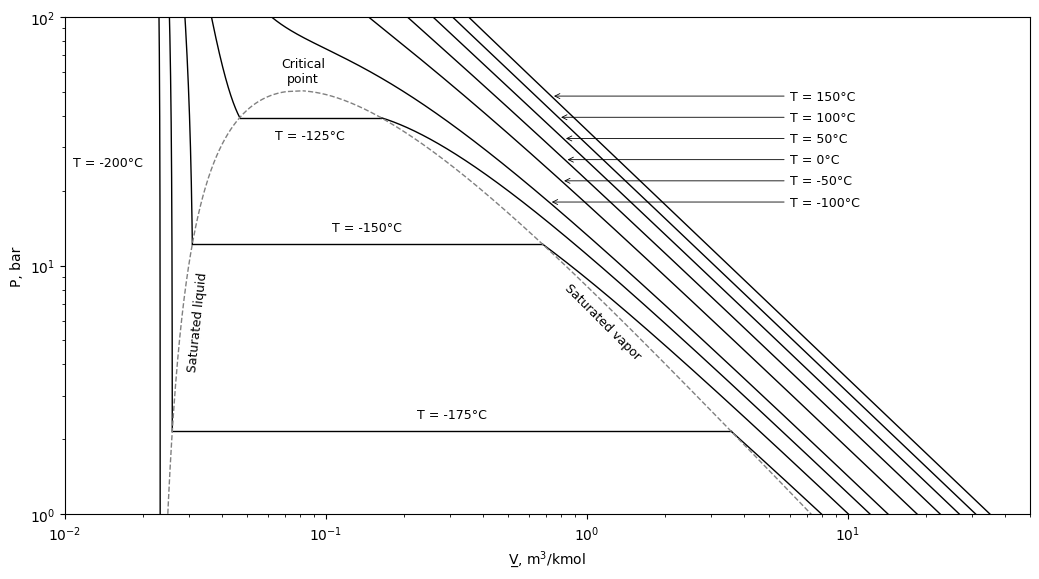

In [13]:
import os

# aspect ratio and axes limits match Fig. 6.4-3 in the 5th edition
fig, ax = plt.subplots(figsize=(10.5, 5.9))
BLACK = "black"


def isotherm_branch(T, V_lo, V_hi, n=2000):
    V = np.logspace(np.log10(V_lo), np.log10(V_hi), n)
    return V, pr.pressure(V, T)


# --- supercritical isotherms (single-valued) ---
supercrit = [150, 100, 50, 0, -50, -100]
iso_curves = {}
for TC in supercrit:
    T = TC + TO_KELVIN
    V, P = isotherm_branch(T, 1.02 * pr.b, 0.05)
    ax.plot(V * M3_PER_KMOL, P / BAR, "-", color=BLACK, lw=1)
    iso_curves[TC] = (V, P)

# temperature key: evenly spaced labels on the right, each joined to its isotherm
# by a horizontal arrow pointing left (as in the book)
P_key = np.logspace(np.log10(48), np.log10(18), len(supercrit))  # bar
V_text = 6.0                                                     # m^3/kmol
for TC, P_lab in zip(supercrit, P_key):
    V, P = iso_curves[TC]
    V_head = np.interp(P_lab * BAR, P[::-1], V[::-1])   # V where isotherm hits P_lab
    ax.annotate(f"T = {TC}°C",
                xy=(V_head * M3_PER_KMOL, P_lab), xycoords="data",
                xytext=(V_text, P_lab), textcoords="data",
                fontsize=9, va="center", ha="left",
                arrowprops=dict(arrowstyle="->", lw=0.6, color=BLACK))

# sub-critical isotherms: liquid branch + tie line + vapor branch
for TC in [-125, -150, -175, -200]:
    T = TC + TO_KELVIN
    ps = pr.vapor_pressure(T)
    vL = pr.molar_volume(T, ps, "liquid")
    vV = pr.molar_volume(T, ps, "vapor")

    VL, PL = isotherm_branch(T, 1.02 * pr.b, vL)
    VV, PV = isotherm_branch(T, vV, 0.5)
    ax.plot(VL * M3_PER_KMOL, PL / BAR, "-", color=BLACK, lw=1)
    ax.plot(VV * M3_PER_KMOL, PV / BAR, "-", color=BLACK, lw=1)
    ax.plot([vL * M3_PER_KMOL, vV * M3_PER_KMOL], [ps / BAR, ps / BAR],
            "-", color=BLACK, lw=1)

    if TC == -200:
        continue  # its tie line lies below the plotted range; label the curve instead
    V_mid = np.sqrt(vL * vV)
    if ps / BAR > 25:   # -125 C: drop below the line to clear the envelope apex
        ax.text(V_mid * M3_PER_KMOL, ps / BAR * 0.90, f"T = {TC}\u00b0C", fontsize=9,
                ha="center", va="top")
    else:
        ax.text(V_mid * M3_PER_KMOL, ps / BAR * 1.1, f"T = {TC}\u00b0C", fontsize=9,
                ha="center", va="bottom")

# -200 C labels the steep near-vertical isotherm at the upper left
ax.text(0.0108, 26, "T = -200\u00b0C", fontsize=9, ha="left", va="center")

# --- saturation envelope (same black line as the isotherms) ---
ax.plot(envelope.vL * M3_PER_KMOL, envelope.P / BAR, "--", color="gray", lw=1)
ax.plot(envelope.vV * M3_PER_KMOL, envelope.P / BAR, "--", color="gray", lw=1)

# --- critical point (text only, as in the book) ---
ax.text(Vc * M3_PER_KMOL, 1.2*pr.Pc / BAR, "Critical\npoint", fontsize=9, ha="center", va="center")

# --- saturated-liquid / saturated-vapor labels along the envelope ---
iL = (envelope.P / BAR - 6.0).abs().idxmin()
rowL = envelope.loc[iL]
ax.text(1.15*rowL.vL * M3_PER_KMOL, rowL.P / BAR, "Saturated liquid",
        rotation=84, rotation_mode="anchor", fontsize=9, ha="center", va="center")
iV = (envelope.P / BAR - 3.5).abs().idxmin()
rowV = envelope.loc[iV]
ax.text(0.5 * rowV.vV * M3_PER_KMOL, rowL.P / BAR, "Saturated vapor",
        rotation=-45, rotation_mode="anchor", fontsize=9, ha="center", va="center")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(0.01, 50)
ax.set_ylim(1.0, 100)
ax.set_xlabel("V\u0332, m$^3$/kmol")   # underbar V = molar volume (book notation)
ax.set_ylabel("P, bar")

os.makedirs("pdf", exist_ok=True)
plt.tight_layout()
plt.savefig("pdf/Fig_6.4-3_thermo.pdf", dpi=300, bbox_inches="tight")
plt.show()
